11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 35ms/step - accuracy: 0.9561 - loss: 0.1442 - val_accuracy: 0.9849 - val_loss: 0.0485
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 35ms/step - accuracy: 0.9866 - loss: 0.0441 - val_accuracy: 0.9884 - val_loss: 0.0341
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9901 - loss: 0.0328 - val_accuracy: 0.9903 - val_loss: 0.0293
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 33ms/step - accuracy: 0.9924 - loss: 0.0248 - val_accuracy: 0.9877 - val_loss: 0.0399
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9938 - loss: 0.0199 - val_accuracy: 0.9913 - val_loss: 0.0290
313/313 - 3s - 9ms/step - accuracy: 0.9913 - loss: 0.0290

Test accuracy: 0.9912999868392944


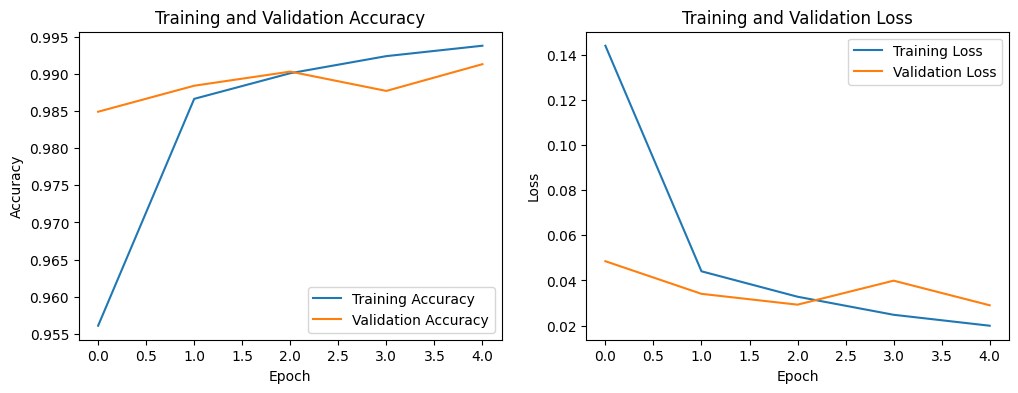

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

train_images = train_images.reshape(
    (train_images.shape[0], 28, 28, 1)
)

test_images = test_images.reshape(
    (test_images.shape[0], 28, 28, 1)
)

train_images = train_images / 255.0
test_images = test_images / 255.0

model = models.Sequential([
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),
    layers.Flatten(),
    layers.Dense(
        64,
        activation='relu'
    ),
    layers.Dense(
        10,
        activation='softmax'
    )
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    validation_data=(test_images, test_labels)
)

test_loss, test_acc = model.evaluate(
    test_images,
    test_labels,
    verbose=2
)

print(f"\nTest accuracy: {test_acc}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()
